In [1]:
import pandas as pd
import os

In [2]:
os.makedirs("../data/enriched", exist_ok=True)

df = pd.read_csv("../data/enriched/ethiopia_fi_enriched.csv")

df.head()

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Baseline year,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN


In [3]:
df["indicator_code"].value_counts
df["indicator_code"].nunique()


34

In [4]:
print("Dataset Shape:", df.shape)

print("\nRecord Types")
print(df["record_type"].value_counts())

print("\nPillars")
print(df["pillar"].value_counts(dropna=False))

print("\nMissing Values")
print(df.isnull().sum())

Dataset Shape: (68, 34)

Record Types
record_type
observation    55
event          10
target          3
Name: count, dtype: int64

Pillars
pillar
USAGE            31
ACCESS           21
NaN              10
GENDER            5
AFFORDABILITY     1
Name: count, dtype: int64

Missing Values
record_id               0
record_type             0
category               58
pillar                 10
indicator               0
indicator_code          0
indicator_direction    10
value_numeric          10
value_text             58
value_type              0
unit                   10
observation_date        0
period_start           58
period_end             58
fiscal_year             0
gender                  0
location                0
region                 68
source_name             0
source_type             0
source_url             12
confidence              0
related_indicator      68
relationship_type      68
impact_direction       68
impact_magnitude       68
impact_estimate        68
lag_months

In [5]:
df["observation_date"] = pd.to_datetime(df["observation_date"], format="mixed")

df["year"] = df["observation_date"].dt.year

df.dtypes[["observation_date","year"]]

observation_date    datetime64[us]
year                         int32
dtype: object

In [6]:
df["year"] = df["observation_date"].dt.year

df[["observation_date", "year"]].head()

,observation_date,year
0,2014-12-31,2014
1,2017-12-31,2017
2,2021-12-31,2021
3,2021-12-31,2021
4,2021-12-31,2021


In [7]:
observations = df[df["record_type"]=="observation"].copy()

events = df[df["record_type"]=="event"].copy()

targets = df[df["record_type"]=="target"].copy()

In [8]:
print(observations.shape)
print(events.shape)
print(targets.shape)

(55, 35)
(10, 35)
(3, 35)


In [9]:
observations["indicator"].value_counts()

indicator
Account Ownership Rate               6
Internet Penetration                 5
Mobile Cellular Subscriptions        5
Mobile Money Agent Network           5
Mobile Money Accounts                5
Commercial Bank Branches             5
Fayda Digital ID Enrollment          3
Mobile Money Account Rate            2
4G Population Coverage               2
P2P Transaction Count                2
Account Ownership Gender Gap         2
Mobile Subscription Penetration      1
P2P Transaction Value                1
ATM Transaction Count                1
ATM Transaction Value                1
P2P/ATM Crossover Ratio              1
Telebirr Registered Users            1
Telebirr Transaction Value           1
M-Pesa Registered Users              1
M-Pesa 90-Day Active Users           1
Mobile Money Activity Rate           1
Data Affordability Index             1
Female Mobile Money Account Share    1
Mobile Phone Gender Gap              1
Name: count, dtype: int64

In [10]:
def get_time_series(df, indicator_code, gender="all"):
    ts = df[
        (df["indicator_code"] == indicator_code) &
        (df["gender"] == gender)
    ].copy()

    ts = ts.sort_values("observation_date")

    return ts

In [11]:
account_ts = get_time_series(observations, "ACC_OWNERSHIP")
internet_ts = get_time_series(observations, "USG_INTERNET_PEN")
agents_ts = get_time_series(observations, "USG_AGENT_NETWORK")

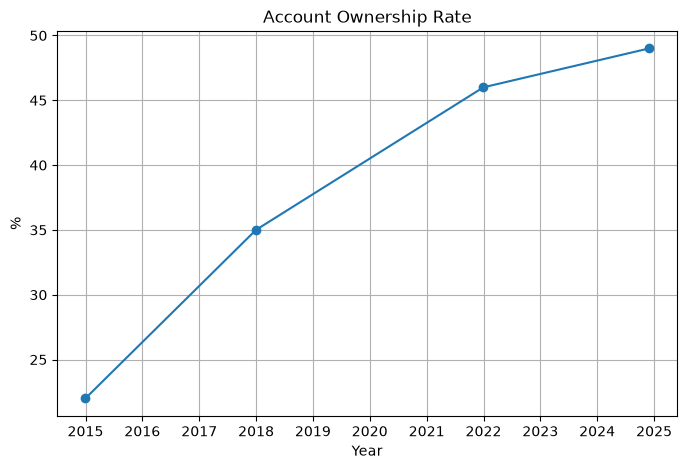

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    account_ts["observation_date"],
    account_ts["value_numeric"],
    marker="o"
)

plt.title("Account Ownership Rate")

plt.xlabel("Year")

plt.ylabel("%")

plt.grid(True)

plt.show()

In [13]:
account_ts = (
    observations[observations["indicator_code"] == "ACC_OWNERSHIP"]
    .sort_values("observation_date")
)

account_ts[
    ["observation_date", "year", "gender", "value_numeric"]
]

,observation_date,year,gender,value_numeric
0,2014-12-31,2014,all,22.0
1,2017-12-31,2017,all,35.0
2,2021-12-31,2021,all,46.0
3,2021-12-31,2021,male,56.0
4,2021-12-31,2021,female,36.0
5,2024-11-29,2024,all,49.0


In [14]:
account_ts = (
    observations[
        (observations["indicator_code"] == "ACC_OWNERSHIP") &
        (observations["gender"] == "all")
    ]
    .sort_values("observation_date")
)

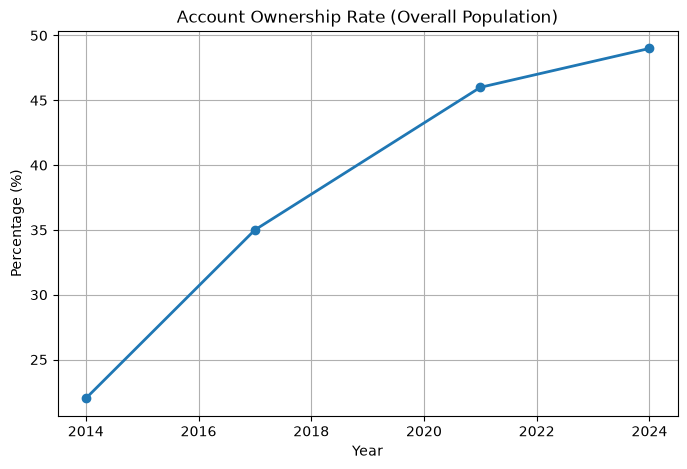

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    account_ts["year"],
    account_ts["value_numeric"],
    marker="o",
    linewidth=2
)

plt.title("Account Ownership Rate (Overall Population)")
plt.xlabel("Year")
plt.ylabel("Percentage (%)")
plt.grid(True)

plt.show()

Visualization


In [16]:
import matplotlib.pyplot as plt

def plot_indicator(df, indicator_code, title, gender="all"):
    ts = (
        df[
            (df["indicator_code"] == indicator_code) &
            (df["gender"] == gender)
        ]
        .sort_values("observation_date")
    )

    plt.figure(figsize=(8,5))

    plt.plot(
        ts["year"],
        ts["value_numeric"],
        marker="o",
        linewidth=2
    )

    plt.title(title)
    plt.xlabel("Year")
    plt.ylabel(ts["unit"].iloc[0])

    plt.grid(True)

    plt.show()

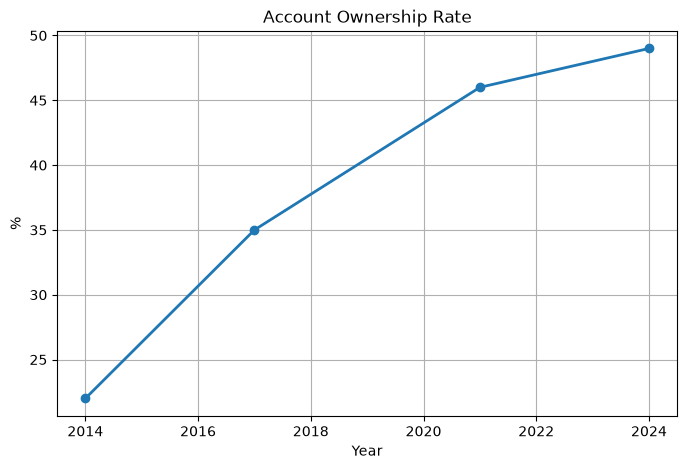

In [17]:
plot_indicator(
    observations,
    "ACC_OWNERSHIP",
    "Account Ownership Rate"
)

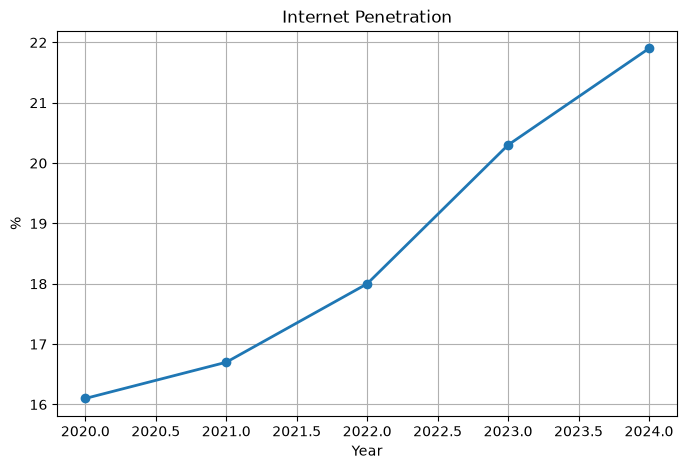

In [18]:
plot_indicator(
    observations,
    "USG_INTERNET_PEN",
    "Internet Penetration"
)

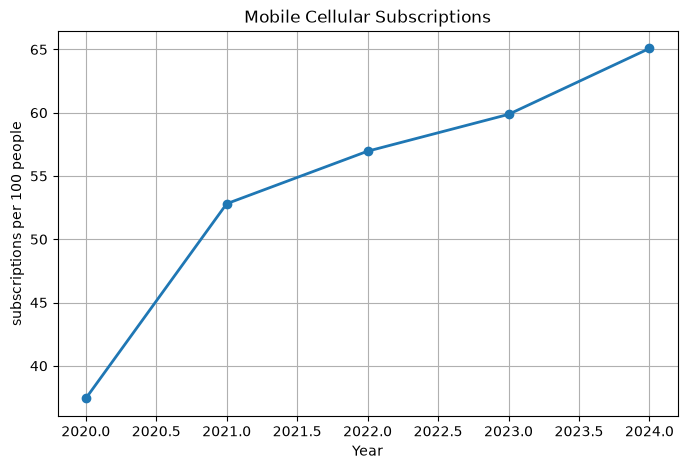

In [19]:
plot_indicator(
    observations,
    "USG_MOBILE_SUB",
    "Mobile Cellular Subscriptions"
)

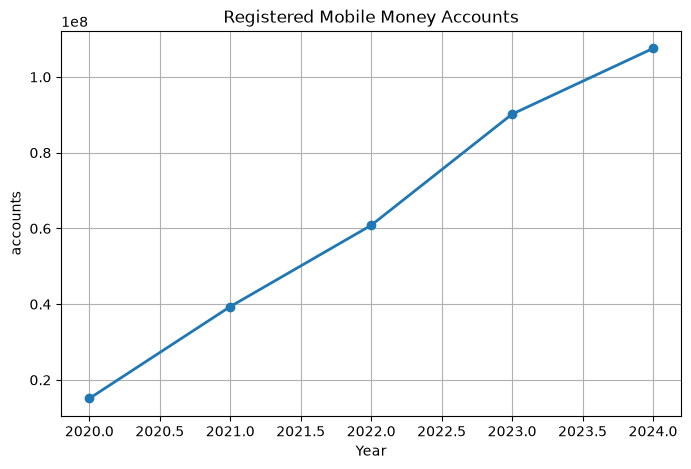

In [20]:
plot_indicator(
    observations,
    "USG_MM_ACCOUNTS",
    "Registered Mobile Money Accounts"
)

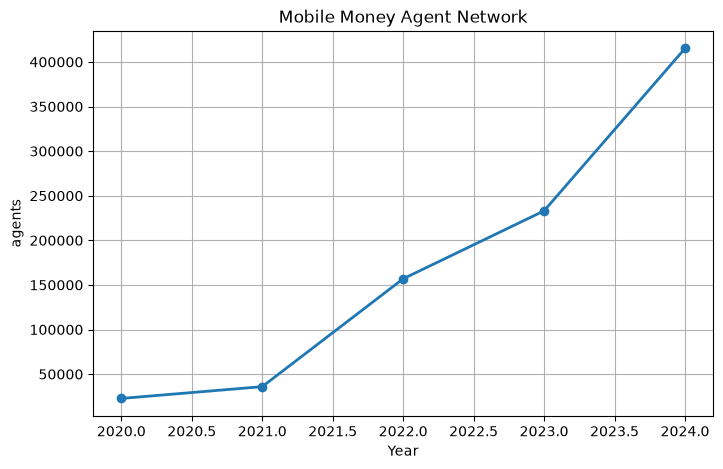

In [21]:
plot_indicator(
    observations,
    "USG_AGENT_NETWORK",
    "Mobile Money Agent Network"
)

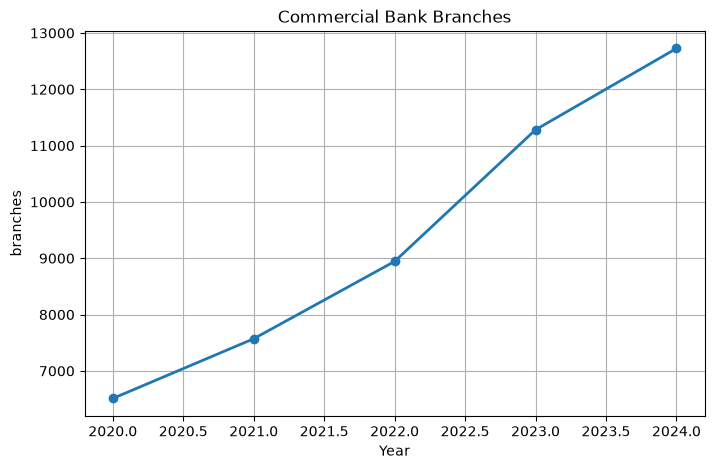

In [22]:
plot_indicator(
    observations,
    "ACC_BANK_BRANCHES",
    "Commercial Bank Branches"
)

Growth Analysis

In [23]:
account_ts = get_time_series(observations, "ACC_OWNERSHIP")

account_ts["growth_rate"] = (
    account_ts["value_numeric"]
    .pct_change() * 100
)

account_ts

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes,year,growth_rate
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,...,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Baseline year,NaN,2014,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,...,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN,2017,59.090909
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,...,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN,2021,31.428571
5,REC_0006,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,49.0,NaN,percentage,...,NaN,NaN,NaN,Example_Trainee,2025-01-20,Account ownership increased from 46% to 49%,Survey Oct-Nov 2024,NaN,2024,6.521739


event overlay 

In [24]:
events[[
    "observation_date",
    "indicator",
    "indicator_code",
    "category"
]].sort_values("observation_date")

,observation_date,indicator,indicator_code,category
33,2021-05-17,Telebirr Launch,EVT_TELEBIRR,product_launch
41,2021-09-01,NFIS-II Strategy Launch,EVT_NFIS2,policy
34,2022-08-01,Safaricom Ethiopia Commercial Launch,EVT_SAFARICOM,market_entry
35,2023-08-01,M-Pesa Ethiopia Launch,EVT_MPESA,product_launch
36,2024-01-01,Fayda Digital ID Program Rollout,EVT_FAYDA,infrastructure
37,2024-07-29,Foreign Exchange Liberalization,EVT_FX_REFORM,policy
38,2024-10-01,P2P Transaction Count Surpasses ATM,EVT_CROSSOVER,milestone
39,2025-10-27,M-Pesa EthSwitch Integration,EVT_MPESA_INTEROP,partnership
42,2025-12-15,Safaricom Ethiopia Price Increase,EVT_SAFCOM_PRICE,pricing
40,2025-12-18,EthioPay Instant Payment System Launch,EVT_ETHIOPAY,infrastructure


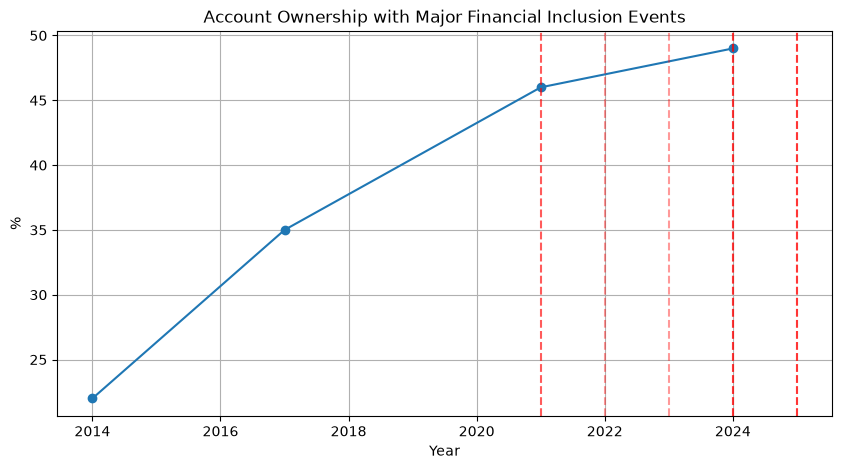

In [25]:
plt.figure(figsize=(10,5))

plt.plot(
    account_ts["year"],
    account_ts["value_numeric"],
    marker="o"
)

for _, event in events.iterrows():
    plt.axvline(
        event["observation_date"].year,
        linestyle="--",
        color="red",
        alpha=0.4
    )

plt.title("Account Ownership with Major Financial Inclusion Events")
plt.xlabel("Year")
plt.ylabel("%")
plt.grid(True)

plt.show()

Correlation Analysis

In [26]:
selected = [
    "ACC_OWNERSHIP",
    "USG_INTERNET_PEN",
    "USG_MOBILE_SUB",
    "USG_AGENT_NETWORK",
    "USG_MM_ACCOUNTS",
    "ACC_BANK_BRANCHES"
]

In [27]:
ts = observations[
    observations["indicator_code"].isin(selected)
].copy()

wide = ts.pivot_table(
    index="year",
    columns="indicator_code",
    values="value_numeric",
    aggfunc="first"
)

wide

indicator_code,ACC_BANK_BRANCHES,ACC_OWNERSHIP,USG_AGENT_NETWORK,USG_INTERNET_PEN,USG_MM_ACCOUNTS,USG_MOBILE_SUB
year,,,,,,
2014,NaN,22.0,NaN,NaN,NaN,NaN
2017,NaN,35.0,NaN,NaN,NaN,NaN
2020,6511.0,NaN,22725.0,16.1,15103804.0,37.42
2021,7571.0,46.0,35964.0,16.7,39359653.0,52.81
2022,8944.0,NaN,156876.0,18.0,60822659.0,56.96
2023,11281.0,NaN,233036.0,20.3,90176046.0,59.87
2024,12725.0,49.0,415084.0,21.9,107523560.0,65.08


In [28]:
corr = wide.corr()

corr

indicator_code,ACC_BANK_BRANCHES,ACC_OWNERSHIP,USG_AGENT_NETWORK,USG_INTERNET_PEN,USG_MM_ACCOUNTS,USG_MOBILE_SUB
indicator_code,,,,,,
ACC_BANK_BRANCHES,1.000000,1.0,0.970730,0.997052,0.993145,0.893269
ACC_OWNERSHIP,1.000000,1.0,1.000000,1.000000,1.000000,1.000000
USG_AGENT_NETWORK,0.970730,1.0,1.000000,0.979783,0.950821,0.833446
USG_INTERNET_PEN,0.997052,1.0,0.979783,1.000000,0.981454,0.859652
USG_MM_ACCOUNTS,0.993145,1.0,0.950821,0.981454,1.000000,0.936564
USG_MOBILE_SUB,0.893269,1.0,0.833446,0.859652,0.936564,1.000000


### Feature Engineering 

In [29]:
account_ts = get_time_series(
    observations,
    "ACC_OWNERSHIP"
)

account_ts = account_ts[[
    "year",
    "observation_date",
    "value_numeric"
]].rename(
    columns={"value_numeric": "account_ownership"}
)

account_ts

,year,observation_date,account_ownership
0,2014,2014-12-31,22.0
1,2017,2017-12-31,35.0
2,2021,2021-12-31,46.0
5,2024,2024-11-29,49.0


In [30]:
account_ts["time_index"] = range(len(account_ts))

account_ts

,year,observation_date,account_ownership,time_index
0,2014,2014-12-31,22.0,0
1,2017,2017-12-31,35.0,1
2,2021,2021-12-31,46.0,2
5,2024,2024-11-29,49.0,3


In [31]:
account_ts.columns

Index(['year', 'observation_date', 'account_ownership', 'time_index'], dtype='str')

In [32]:
account_ts["telebirr"] = (
    account_ts["year"] >= 2021
).astype(int)

account_ts["mpesa"] = (
    account_ts["year"] >= 2023
).astype(int)

account_ts["fayda"] = (
    account_ts["year"] >= 2024
).astype(int)

account_ts

,year,observation_date,account_ownership,time_index,telebirr,mpesa,fayda
0,2014,2014-12-31,22.0,0,0,0,0
1,2017,2017-12-31,35.0,1,0,0,0
2,2021,2021-12-31,46.0,2,1,0,0
5,2024,2024-11-29,49.0,3,1,1,1


### merge dataset

In [33]:
def indicator_series(df, code, column_name):
    ts = get_time_series(df, code)

    return ts[["year", "value_numeric"]].rename(
        columns={"value_numeric": column_name}
    )

In [34]:
internet = indicator_series(
    observations,
    "USG_INTERNET_PEN",
    "internet_penetration"
)

account_ts = account_ts.merge(
    internet,
    on="year",
    how="left"
)

In [35]:
mobile = indicator_series(
    observations,
    "USG_MOBILE_SUB",
    "mobile_subscriptions"
)

account_ts = account_ts.merge(
    mobile,
    on="year",
    how="left"
)

In [36]:
agents = indicator_series(
    observations,
    "USG_AGENT_NETWORK",
    "agent_network"
)

account_ts = account_ts.merge(
    agents,
    on="year",
    how="left"
)

In [37]:
branches = indicator_series(
    observations,
    "ACC_BANK_BRANCHES",
    "bank_branches"
)

account_ts = account_ts.merge(
    branches,
    on="year",
    how="left"
)

In [38]:
account_ts

,year,observation_date,account_ownership,time_index,telebirr,mpesa,fayda,internet_penetration,mobile_subscriptions,agent_network,bank_branches
0,2014,2014-12-31,22.0,0,0,0,0,NaN,NaN,NaN,NaN
1,2017,2017-12-31,35.0,1,0,0,0,NaN,NaN,NaN,NaN
2,2021,2021-12-31,46.0,2,1,0,0,16.7,52.81,35964.0,7571.0
3,2024,2024-11-29,49.0,3,1,1,1,21.9,65.08,415084.0,12725.0


In [39]:
account_ts.isnull().sum()

year                    0
observation_date        0
account_ownership       0
time_index              0
telebirr                0
mpesa                   0
fayda                   0
internet_penetration    2
mobile_subscriptions    2
agent_network           2
bank_branches           2
dtype: int64

## MOdeling preparation


In [40]:
import pandas as pd

years = pd.DataFrame({
    "year": range(2014,2025)
})

years

,year
0,2014
1,2015
2,2016
3,2017
4,2018
5,2019
6,2020
7,2021
8,2022
9,2023


In [41]:
ownership = df[
    (df["indicator_code"] == "ACC_OWNERSHIP")&
    (df["gender"] == "all")
].copy()

ownership["year"] = pd.to_datetime(
    ownership["observation_date"], format="mixed"
).dt.year

ownership = ownership[["year","value_numeric"]]


ownership.columns = ["year", "account_ownership"]

ownership

,year,account_ownership
0,2014,22.0
1,2017,35.0
2,2021,46.0
5,2024,49.0
30,2025,70.0


In [42]:
ownership_yearly = years.merge(
    ownership,
    on="year",
    how="left"
)

ownership_yearly

,year,account_ownership
0,2014,22.0
1,2015,NaN
2,2016,NaN
3,2017,35.0
4,2018,NaN
5,2019,NaN
6,2020,NaN
7,2021,46.0
8,2022,NaN
9,2023,NaN


In [43]:
ownership_yearly["account_interp"] = (
    ownership_yearly["account_ownership"]
    .interpolate(method="linear")
)

ownership_yearly

,year,account_ownership,account_interp
0,2014,22.0,22.000000
1,2015,NaN,26.333333
2,2016,NaN,30.666667
3,2017,35.0,35.000000
4,2018,NaN,37.750000
5,2019,NaN,40.500000
6,2020,NaN,43.250000
7,2021,46.0,46.000000
8,2022,NaN,47.000000
9,2023,NaN,48.000000


In [44]:
ownership_yearly["is_observed"] = (
    ownership_yearly["account_ownership"]
    .notna()
)

ownership_yearly

,year,account_ownership,account_interp,is_observed
0,2014,22.0,22.000000,True
1,2015,NaN,26.333333,False
2,2016,NaN,30.666667,False
3,2017,35.0,35.000000,True
4,2018,NaN,37.750000,False
5,2019,NaN,40.500000,False
6,2020,NaN,43.250000,False
7,2021,46.0,46.000000,True
8,2022,NaN,47.000000,False
9,2023,NaN,48.000000,False


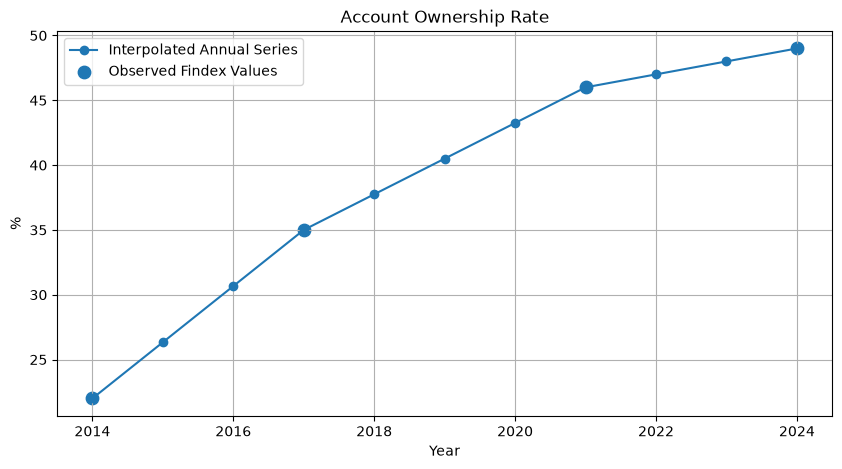

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    ownership_yearly["year"],
    ownership_yearly["account_interp"],
    marker="o",
    label="Interpolated Annual Series"
)

plt.scatter(
    ownership_yearly.loc[
        ownership_yearly["is_observed"],
        "year"
    ],
    ownership_yearly.loc[
        ownership_yearly["is_observed"],
        "account_ownership"
    ],
    s=80,
    label="Observed Findex Values"
)

plt.title("Account Ownership Rate")
plt.xlabel("Year")
plt.ylabel("%")

plt.grid(True)
plt.legend()

plt.show()

In [46]:
def get_indicator(df, indicator_code, column_name):
    """
    Extract one indicator as a yearly dataframe.
    """

    temp = df[
        (df["indicator_code"] == indicator_code) &
        (df["record_type"] == "observation")
    ].copy()

    temp["year"] = pd.to_datetime(
        temp["observation_date"],
        format="mixed"
    ).dt.year

    temp = temp[["year", "value_numeric"]]

    temp.columns = ["year", column_name]

    return temp

In [47]:
internet = get_indicator(
    df,
    "USG_INTERNET_PEN",
    "internet_penetration"
)

mobile = get_indicator(
    df,
    "USG_MOBILE_SUB",
    "mobile_subscriptions"
)

agents = get_indicator(
    df,
    "USG_AGENT_NETWORK",
    "agent_network"
)

branches = get_indicator(
    df,
    "ACC_BANK_BRANCHES",
    "bank_branches"
)

In [48]:
internet

,year,internet_penetration
43,2020,16.1
44,2021,16.7
45,2022,18.0
46,2023,20.3
47,2024,21.9


In [49]:
model_df = ownership_yearly.copy()

for table in [internet, mobile, agents, branches]:
    model_df = model_df.merge(
        table,
        on="year",
        how="left"
    )

In [50]:
model_df.head(15)

,year,account_ownership,account_interp,is_observed,internet_penetration,mobile_subscriptions,agent_network,bank_branches
0,2014,22.0,22.000000,True,NaN,NaN,NaN,NaN
1,2015,NaN,26.333333,False,NaN,NaN,NaN,NaN
2,2016,NaN,30.666667,False,NaN,NaN,NaN,NaN
3,2017,35.0,35.000000,True,NaN,NaN,NaN,NaN
4,2018,NaN,37.750000,False,NaN,NaN,NaN,NaN
5,2019,NaN,40.500000,False,NaN,NaN,NaN,NaN
6,2020,NaN,43.250000,False,16.1,37.42,22725.0,6511.0
7,2021,46.0,46.000000,True,16.7,52.81,35964.0,7571.0
8,2022,NaN,47.000000,False,18.0,56.96,156876.0,8944.0
9,2023,NaN,48.000000,False,20.3,59.87,233036.0,11281.0


In [51]:
model_df["telebirr"] = (model_df["year"] >= 2021).astype(int)
model_df["mpesa"] = (model_df["year"] >= 2023).astype(int)
model_df["fayda"] = (model_df["year"] >= 2024).astype(int)

In [52]:
model_df[
    ["year","telebirr", "mpesa","fayda"]]


,year,telebirr,mpesa,fayda
0,2014,0,0,0
1,2015,0,0,0
2,2016,0,0,0
3,2017,0,0,0
4,2018,0,0,0
5,2019,0,0,0
6,2020,0,0,0
7,2021,1,0,0
8,2022,1,0,0
9,2023,1,1,0


In [53]:
model_df

,year,account_ownership,account_interp,is_observed,internet_penetration,mobile_subscriptions,agent_network,bank_branches,telebirr,mpesa,fayda
0,2014,22.0,22.000000,True,NaN,NaN,NaN,NaN,0,0,0
1,2015,NaN,26.333333,False,NaN,NaN,NaN,NaN,0,0,0
2,2016,NaN,30.666667,False,NaN,NaN,NaN,NaN,0,0,0
3,2017,35.0,35.000000,True,NaN,NaN,NaN,NaN,0,0,0
4,2018,NaN,37.750000,False,NaN,NaN,NaN,NaN,0,0,0
5,2019,NaN,40.500000,False,NaN,NaN,NaN,NaN,0,0,0
6,2020,NaN,43.250000,False,16.1,37.42,22725.0,6511.0,0,0,0
7,2021,46.0,46.000000,True,16.7,52.81,35964.0,7571.0,1,0,0
8,2022,NaN,47.000000,False,18.0,56.96,156876.0,8944.0,1,0,0
9,2023,NaN,48.000000,False,20.3,59.87,233036.0,11281.0,1,1,0


In [54]:
predictor_cols = [
    "internet_penetration",
    "mobile_subscriptions",
    "agent_network",
    "bank_branches"
]

model_df[predictor_cols] = (
    model_df[predictor_cols]
    .bfill()
)


model_df.isna().sum()

year                    0
account_ownership       7
account_interp          0
is_observed             0
internet_penetration    0
mobile_subscriptions    0
agent_network           0
bank_branches           0
telebirr                0
mpesa                   0
fayda                   0
dtype: int64

In [55]:
model_df

,year,account_ownership,account_interp,is_observed,internet_penetration,mobile_subscriptions,agent_network,bank_branches,telebirr,mpesa,fayda
0,2014,22.0,22.000000,True,16.1,37.42,22725.0,6511.0,0,0,0
1,2015,NaN,26.333333,False,16.1,37.42,22725.0,6511.0,0,0,0
2,2016,NaN,30.666667,False,16.1,37.42,22725.0,6511.0,0,0,0
3,2017,35.0,35.000000,True,16.1,37.42,22725.0,6511.0,0,0,0
4,2018,NaN,37.750000,False,16.1,37.42,22725.0,6511.0,0,0,0
5,2019,NaN,40.500000,False,16.1,37.42,22725.0,6511.0,0,0,0
6,2020,NaN,43.250000,False,16.1,37.42,22725.0,6511.0,0,0,0
7,2021,46.0,46.000000,True,16.7,52.81,35964.0,7571.0,1,0,0
8,2022,NaN,47.000000,False,18.0,56.96,156876.0,8944.0,1,0,0
9,2023,NaN,48.000000,False,20.3,59.87,233036.0,11281.0,1,1,0


In [63]:
model_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  11 non-null     int64  
 1   account_ownership     4 non-null      float64
 2   account_interp        11 non-null     float64
 3   is_observed           11 non-null     bool   
 4   internet_penetration  11 non-null     float64
 5   mobile_subscriptions  11 non-null     float64
 6   agent_network         11 non-null     float64
 7   bank_branches         11 non-null     float64
 8   telebirr              11 non-null     int64  
 9   mpesa                 11 non-null     int64  
 10  fayda                 11 non-null     int64  
dtypes: bool(1), float64(6), int64(4)
memory usage: 1023.0 bytes


eda 

In [57]:
model_df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,11.0,2019.000000,3.316625,2014.00,2016.500000,2019.00,2021.500,2024.00
account_ownership,4.0,38.000000,12.247449,22.00,31.750000,40.50,46.750,49.00
account_interp,11.0,38.681818,9.217647,22.00,32.833333,40.50,46.500,49.00
internet_penetration,11.0,17.236364,2.025968,16.10,16.100000,16.10,17.350,21.90
mobile_subscriptions,11.0,45.150909,11.091913,37.42,37.420000,37.42,54.885,65.08
agent_network,11.0,90912.272727,128531.520547,22725.00,22725.000000,22725.00,96420.000,415084.00
bank_branches,11.0,7827.090909,2221.637615,6511.00,6511.000000,6511.00,8257.500,12725.00
telebirr,11.0,0.363636,0.504525,0.00,0.000000,0.00,1.000,1.00
mpesa,11.0,0.181818,0.404520,0.00,0.000000,0.00,0.000,1.00
fayda,11.0,0.090909,0.301511,0.00,0.000000,0.00,0.000,1.00


In [58]:

corr = model_df.drop(columns=["is_observed"]).corr()

corr

,year,account_ownership,account_interp,internet_penetration,mobile_subscriptions,agent_network,bank_branches,telebirr,mpesa,fayda
year,1.000000,0.971806,0.975310,0.784299,0.863060,0.758161,0.808445,0.836660,0.670820,0.500000
account_ownership,0.971806,1.000000,1.000000,0.663429,0.868108,0.620115,0.703470,0.895669,0.598764,0.598764
account_interp,0.975310,1.000000,1.000000,0.638177,0.752883,0.609485,0.666855,0.758466,0.526625,0.371261
internet_penetration,0.784299,0.663429,0.638177,1.000000,0.909767,0.986740,0.997181,0.778216,0.942874,0.763464
mobile_subscriptions,0.863060,0.868108,0.752883,0.909767,1.000000,0.883839,0.937008,0.967029,0.772208,0.595905
agent_network,0.758161,0.620115,0.609485,0.986740,0.883839,1.000000,0.978663,0.736053,0.896833,0.836492
bank_branches,0.808445,0.703470,0.666855,0.997181,0.937008,0.978663,1.000000,0.821917,0.929326,0.731196
telebirr,0.836660,0.895669,0.758466,0.778216,0.967029,0.736053,0.821917,1.000000,0.623610,0.418330
mpesa,0.670820,0.598764,0.526625,0.942874,0.772208,0.896833,0.929326,0.623610,1.000000,0.670820
fayda,0.500000,0.598764,0.371261,0.763464,0.595905,0.836492,0.731196,0.418330,0.670820,1.000000


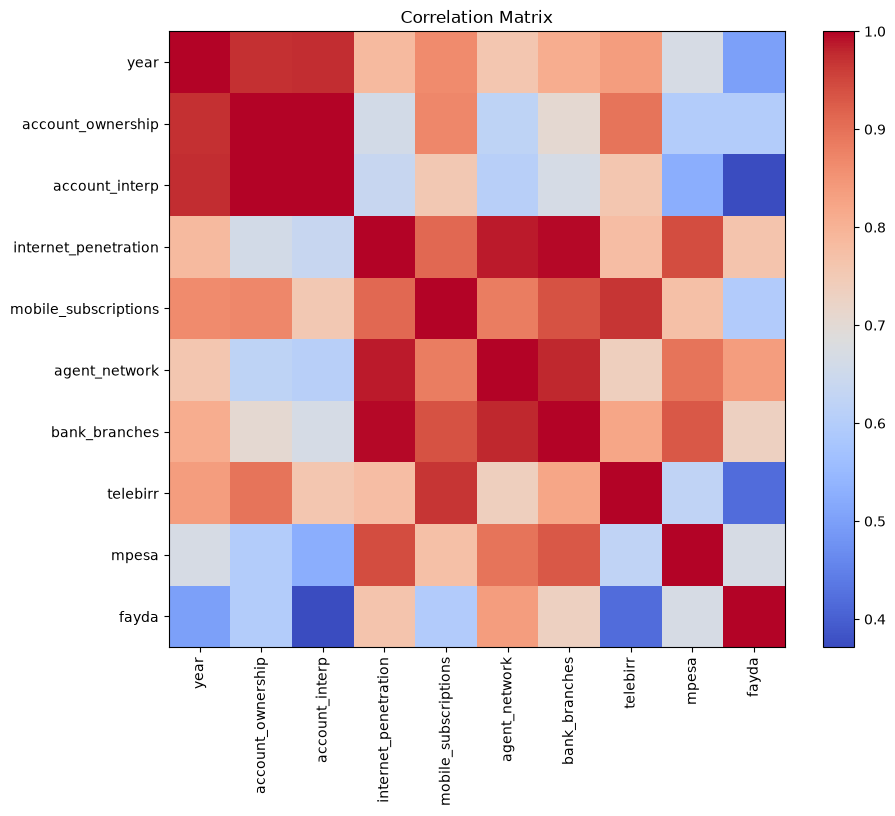

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.imshow(corr, cmap="coolwarm")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)

plt.yticks(range(len(corr.columns)), corr.columns)

plt.colorbar()

plt.title("Correlation Matrix")

plt.show()

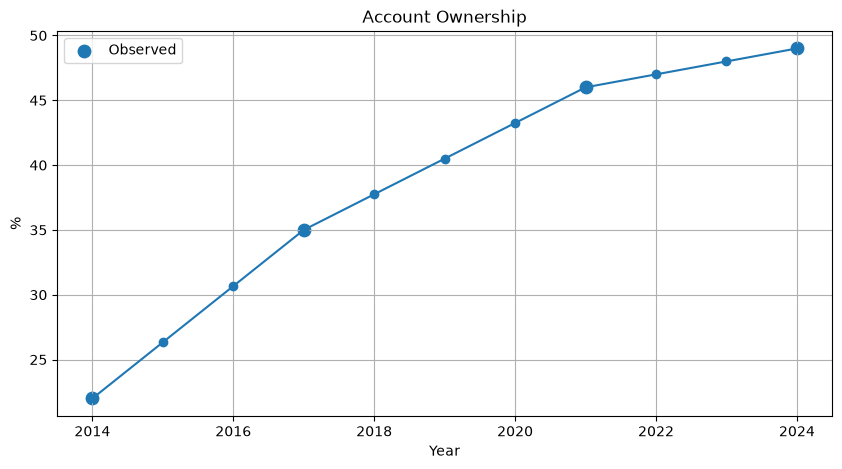

In [60]:
plt.figure(figsize=(10,5))

plt.plot(
    model_df["year"],
    model_df["account_interp"],
    marker="o"
)

plt.scatter(
    model_df.loc[model_df["is_observed"],"year"],
    model_df.loc[model_df["is_observed"],"account_ownership"],
    s=80,
    label="Observed"
)

plt.grid(True)

plt.title("Account Ownership")

plt.xlabel("Year")

plt.ylabel("%")

plt.legend()

plt.show()

In [61]:
from sklearn.preprocessing import MinMaxScaler

cols = [
    "account_interp",
    "internet_penetration",
    "mobile_subscriptions",
    "agent_network",
    "bank_branches"
]

scaled = pd.DataFrame(
    MinMaxScaler().fit_transform(model_df[cols]),
    columns=cols
)

scaled["year"] = model_df["year"]

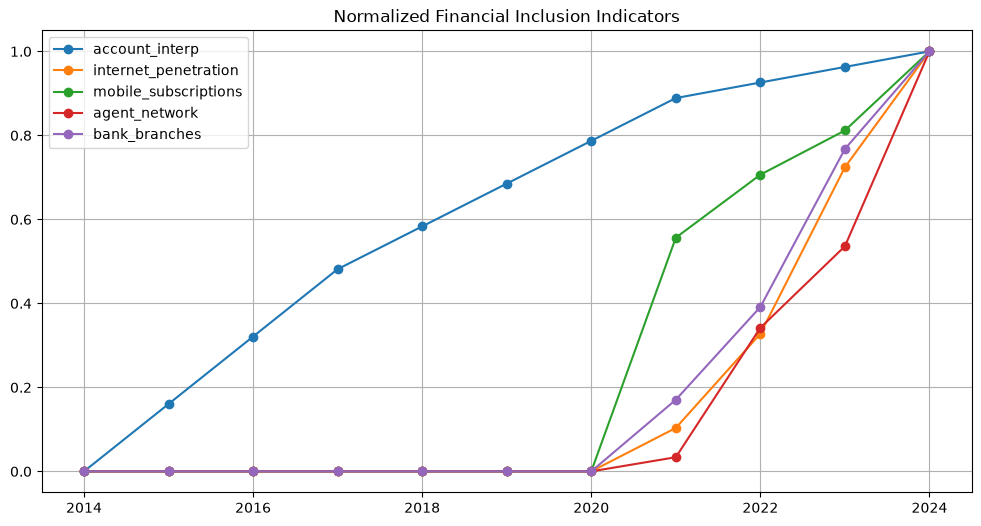

In [62]:
plt.figure(figsize=(12,6))

for c in cols:
    plt.plot(
        scaled["year"],
        scaled[c],
        marker="o",
        label=c
    )

plt.legend()

plt.grid(True)

plt.title("Normalized Financial Inclusion Indicators")

plt.show()

In [64]:
model_df.to_csv("../data/model-ready/ethio_modeling.csv", index= False)

print("modeling data saved successfully")

modeling data saved successfully
